### Configuration, inputs & outputs

In [1]:
from pipeline_utils import make_case2_paths, load_expert_rating_labels
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
N_SPLITS = 5
VAL_FRAC = 0.15
NUM_EPOCHS = 50
PATIENCE = 7
BATCH_SIZE = 32
CATEGORIES = [f"cat{i}" for i in range(1, 6)]

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Configure paths
paths = make_case2_paths()

PROJECT_DIR = paths["project"]
PROC_DIR = paths["proc"]

print(f"Project directory: {PROJECT_DIR}")
print(f"Processed data directory: {PROC_DIR}")

# Input files
expert_rating_table = PROC_DIR / "expert_rating" / "expert_rating_summary.csv"
fold_table = PROC_DIR / "ml_cv_fold_assignment.csv"
image_dir = PROC_DIR / "images_clean"

df_clean = load_expert_rating_labels(expert_rating_table)
fold_df = pd.read_csv(fold_table)
print(f"Loaded {len(fold_df)} labeled figures across {fold_df['fold'].nunique()} folds")

# Output files
checkpoint_dir = PROC_DIR / "ml_model" / "resnet18"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

cat_mapping_file = checkpoint_dir / "cat_mapping.json"
fold_results_table = checkpoint_dir / "resnet18_cv_fold_results.csv"
predictions_table = checkpoint_dir / "resnet18_cv_predictions.csv"
history_table = checkpoint_dir / "resnet18_cv_training_history.csv"
summary_table = checkpoint_dir / "resnet18_cv_summary.csv"
confusion_table = checkpoint_dir / "resnet18_cv_confusion_matrix.csv"
confusion_fig = checkpoint_dir / "resnet18_cv_confusion_matrix.png"

with open(cat_mapping_file, "w") as f:
    json.dump({cat: i for i, cat in enumerate(CATEGORIES)}, f)

print(f"Checkpoint directory: {checkpoint_dir}")

Using device: mps
Project directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Processed data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity
Loaded 1267 labeled figures across 5 folds
Checkpoint directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18


### Dataset class and transforms

In [2]:
class PDXDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["file_path"]).convert("RGB")
        label = int(row["label"])
        if self.transform:
            image = self.transform(image)
        return image, label


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # zoom in slightly
    # No RandomHorizontalFlip: these are tumor-volume-over-time curves, and mirroring
    # left-right inverts the time axis -- not a label-preserving augmentation here.
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # small lighting shifts
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

### Per-fold training and evaluation

Each fold's held-out test partition is scored exactly once, by the checkpoint that performed best on that fold's *validation* split (carved out of the training pool only -- the test partition is never used for early stopping or checkpoint selection).

In [3]:
def compute_class_weights(train_df):
    counts = train_df["rating_merge"].value_counts()
    class_counts = [counts.get(cat, 1) for cat in CATEGORIES]
    total = sum(class_counts)
    return [total / (len(CATEGORIES) * c) for c in class_counts]


def build_model(num_classes=5):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)


def train_one_fold(fold_idx, fold_df, image_dir, checkpoint_dir):
    set_seed(RANDOM_STATE)

    test_df = fold_df[fold_df["fold"] == fold_idx].copy()
    train_pool_df = fold_df[fold_df["fold"] != fold_idx].copy()

    train_df, val_df = train_test_split(
        train_pool_df, test_size=VAL_FRAC, stratify=train_pool_df["label"], random_state=RANDOM_STATE
    )

    for split_df in (train_df, val_df, test_df):
        split_df["file_path"] = split_df["figure_id"].apply(lambda x: str(image_dir / f"{x}.png"))

    weights = compute_class_weights(train_df)
    class_weights_t = torch.FloatTensor(weights).to(device)

    train_dataset = PDXDataset(train_df, transform=train_transforms)
    val_dataset = PDXDataset(val_df, transform=test_transforms)
    test_dataset = PDXDataset(test_df, transform=test_transforms)

    target_list = torch.tensor(train_df["label"].values)
    sample_weights = [weights[t] for t in target_list]
    sampler_gen = torch.Generator().manual_seed(RANDOM_STATE)
    sampler = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True, generator=sampler_gen
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = build_model()
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = optim.Adam([
        {"params": model.layer1.parameters(), "lr": 1e-6},
        {"params": model.layer2.parameters(), "lr": 1e-6},
        {"params": model.layer3.parameters(), "lr": 1e-5},
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-4},
    ], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=3)

    checkpoint_path = checkpoint_dir / f"pdx_resnet18_fold{fold_idx}_best.pth"

    history = []
    best_val_acc = 0.0
    trigger_times = 0
    stopped_epoch = NUM_EPOCHS

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)
        avg_train_loss = running_train_loss / len(train_loader.dataset)

        model.eval()
        running_val_loss = 0.0
        val_preds, val_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
        avg_val_loss = running_val_loss / len(val_loader.dataset)
        val_acc = balanced_accuracy_score(val_labels, val_preds)

        scheduler.step(avg_val_loss)
        history.append({
            "fold": fold_idx, "epoch": epoch + 1,
            "train_loss": avg_train_loss, "val_loss": avg_val_loss, "val_balanced_accuracy": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_path)
            trigger_times = 0
        else:
            trigger_times += 1

        if trigger_times >= PATIENCE:
            stopped_epoch = epoch + 1
            break

    # Reload the best checkpoint and score the held-out fold exactly once
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.numpy())
    test_figure_ids = test_df["figure_id"].tolist()

    precision, recall, f1, _ = precision_recall_fscore_support(
        test_labels, test_preds, average="macro", zero_division=0
    )
    test_balanced_acc = balanced_accuracy_score(test_labels, test_preds)

    fold_result = {
        "fold": fold_idx,
        "n_train": len(train_df),
        "n_val": len(val_df),
        "n_test": len(test_df),
        "stopped_epoch": stopped_epoch,
        "best_val_balanced_accuracy": best_val_acc,
        "test_macro_precision": precision,
        "test_macro_recall": recall,
        "test_macro_f1": f1,
        "test_balanced_accuracy": test_balanced_acc,
    }

    predictions_df = pd.DataFrame({
        "figure_id": test_figure_ids,
        "fold": fold_idx,
        "true_label": test_labels,
        "pred_label": test_preds,
    })

    return fold_result, predictions_df, pd.DataFrame(history)

### Run 5-fold cross-validation

In [4]:
fold_results = []
all_predictions = []
all_history = []

for fold_idx in sorted(fold_df["fold"].unique()):
    result, predictions_df, history_df = train_one_fold(fold_idx, fold_df, image_dir, checkpoint_dir)
    print(
        f"Fold {fold_idx}: stopped at epoch {result['stopped_epoch']} "
        f"(best val balanced acc {result['best_val_balanced_accuracy']:.4f}); "
        f"test macro F1 {result['test_macro_f1']:.4f}, "
        f"test balanced acc {result['test_balanced_accuracy']:.4f}"
    )
    fold_results.append(result)
    all_predictions.append(predictions_df)
    all_history.append(history_df)

Fold 0: stopped at epoch 27 (best val balanced acc 0.8907); test macro F1 0.8556, test balanced acc 0.8588


Fold 1: stopped at epoch 21 (best val balanced acc 0.8307); test macro F1 0.8390, test balanced acc 0.8516


Fold 2: stopped at epoch 29 (best val balanced acc 0.8650); test macro F1 0.8436, test balanced acc 0.8426


Fold 3: stopped at epoch 20 (best val balanced acc 0.8551); test macro F1 0.8196, test balanced acc 0.8364


Fold 4: stopped at epoch 35 (best val balanced acc 0.8686); test macro F1 0.8590, test balanced acc 0.8644


### Aggregate cross-validated performance

In [5]:
fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv(fold_results_table, index=False)
print(f"Saved per-fold results to {fold_results_table}")
fold_results_df

Saved per-fold results to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_cv_fold_results.csv


,fold,n_train,n_val,n_test,stopped_epoch,best_val_balanced_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_balanced_accuracy
0,0,861,152,254,27,0.890681,0.853889,0.858826,0.855597,0.858826
1,1,861,152,254,21,0.830711,0.831252,0.851627,0.839006,0.851627
2,2,861,153,253,29,0.864988,0.849820,0.842629,0.843600,0.842629
3,3,861,153,253,20,0.855138,0.809342,0.836425,0.819564,0.836425
4,4,861,153,253,35,0.868565,0.856412,0.864359,0.859004,0.864359


In [6]:
metric_cols = ["test_macro_precision", "test_macro_recall", "test_macro_f1", "test_balanced_accuracy"]
summary = fold_results_df[metric_cols].agg(["mean", "std"]).T
summary.to_csv(summary_table)

print(f"Saved CV summary to {summary_table}")
print("\nMean \u00b1 SD across 5 folds:")
print(summary)

Saved CV summary to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_cv_summary.csv

Mean ± SD across 5 folds:
                            mean       std
test_macro_precision    0.840143  0.019844
test_macro_recall       0.850773  0.011427
test_macro_f1           0.843354  0.015650
test_balanced_accuracy  0.850773  0.011427


### QC: out-of-fold prediction coverage

In [7]:
oof_predictions_df = pd.concat(all_predictions, ignore_index=True).sort_values("figure_id")
oof_predictions_df.to_csv(predictions_table, index=False)

history_df = pd.concat(all_history, ignore_index=True)
history_df.to_csv(history_table, index=False)

n_unique_figures = oof_predictions_df["figure_id"].nunique()
print(f"Out-of-fold predictions cover {n_unique_figures} unique figures (expected {len(fold_df)})")
assert n_unique_figures == len(fold_df), "Every figure should be predicted exactly once across folds"

print(f"Saved out-of-fold predictions to {predictions_table}")
print(f"Saved training history to {history_table}")

Out-of-fold predictions cover 1267 unique figures (expected 1267)
Saved out-of-fold predictions to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_cv_predictions.csv
Saved training history to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_cv_training_history.csv


### Pooled out-of-fold confusion matrix

Saved pooled out-of-fold confusion matrix to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_cv_confusion_matrix.csv
      cat1  cat2  cat3  cat4  cat5
cat1   282    18     0     4     1
cat2    32   304    22     1     0
cat3     1    14   248    36     0
cat4     0     0    19   172    22
cat5     0     0     0    14    77


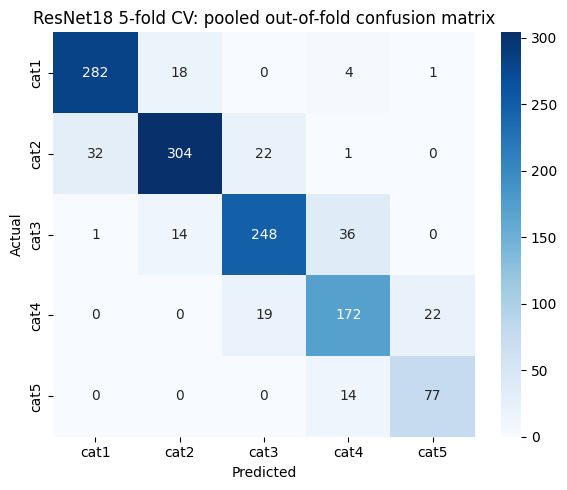

Saved confusion matrix figure to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_cv_confusion_matrix.png


In [8]:
cm = confusion_matrix(oof_predictions_df["true_label"], oof_predictions_df["pred_label"])
cm_df = pd.DataFrame(cm, index=CATEGORIES, columns=CATEGORIES)
cm_df.to_csv(confusion_table)

print(f"Saved pooled out-of-fold confusion matrix to {confusion_table}")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet18 5-fold CV: pooled out-of-fold confusion matrix")
plt.tight_layout()
plt.savefig(confusion_fig, dpi=200)
plt.show()

print(f"Saved confusion matrix figure to {confusion_fig}")

### Per-fold training curves

One dual-axis plot per fold (training pool loss, validation loss, validation balanced accuracy), with the checkpointed "best" epoch marked -- the same epoch used for that fold's held-out test evaluation above.

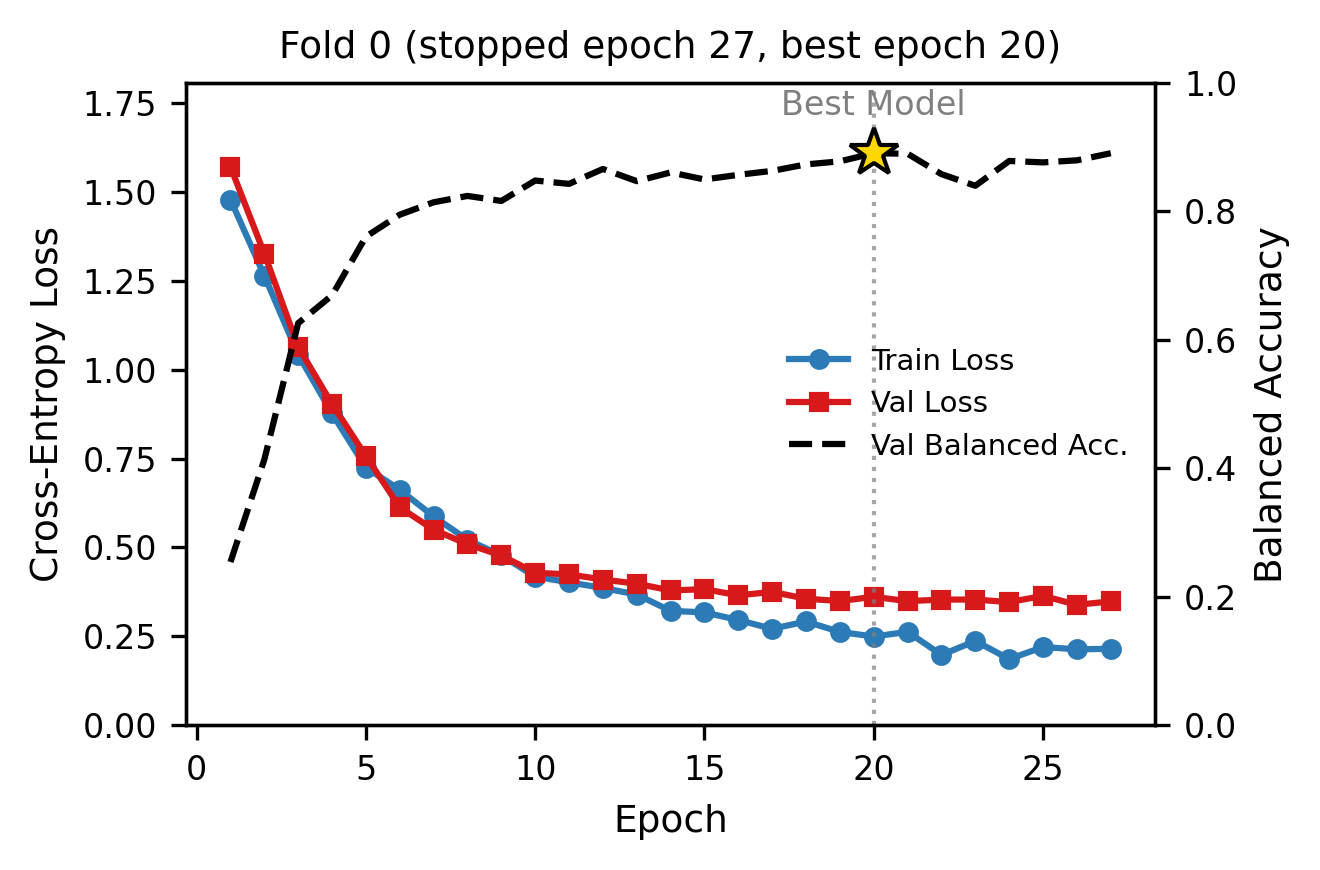

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_fold0_training_curve.png


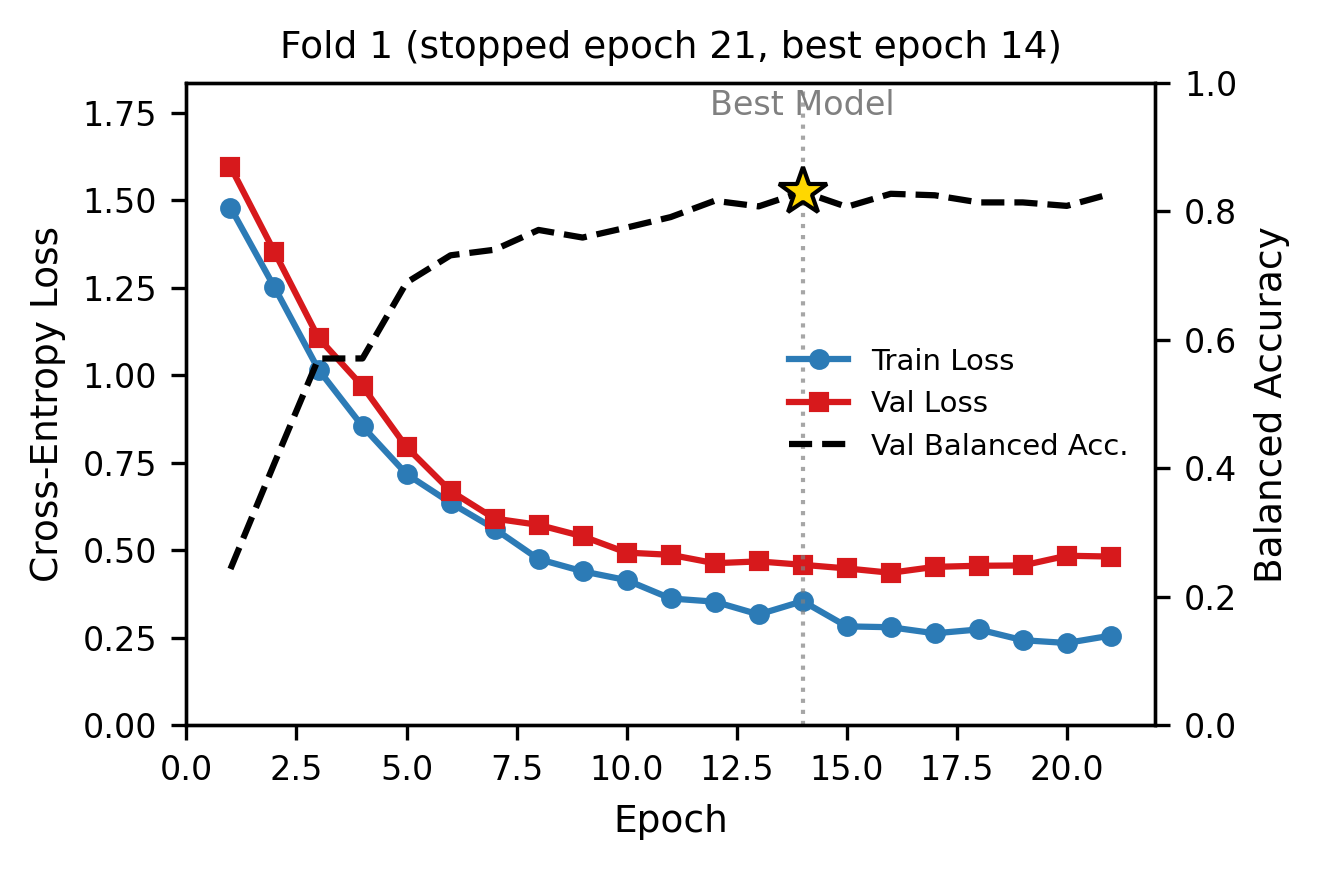

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_fold1_training_curve.png


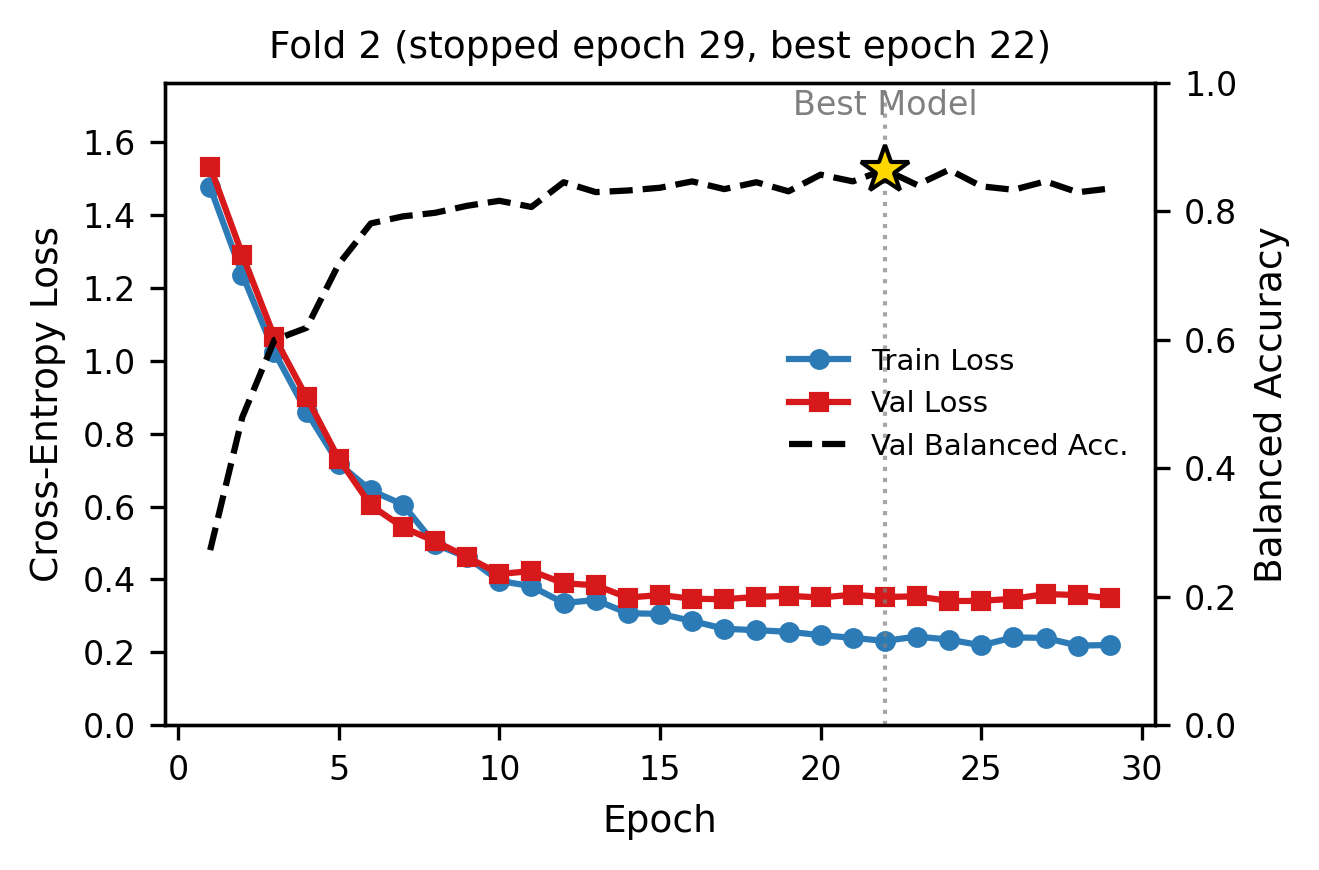

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_fold2_training_curve.png


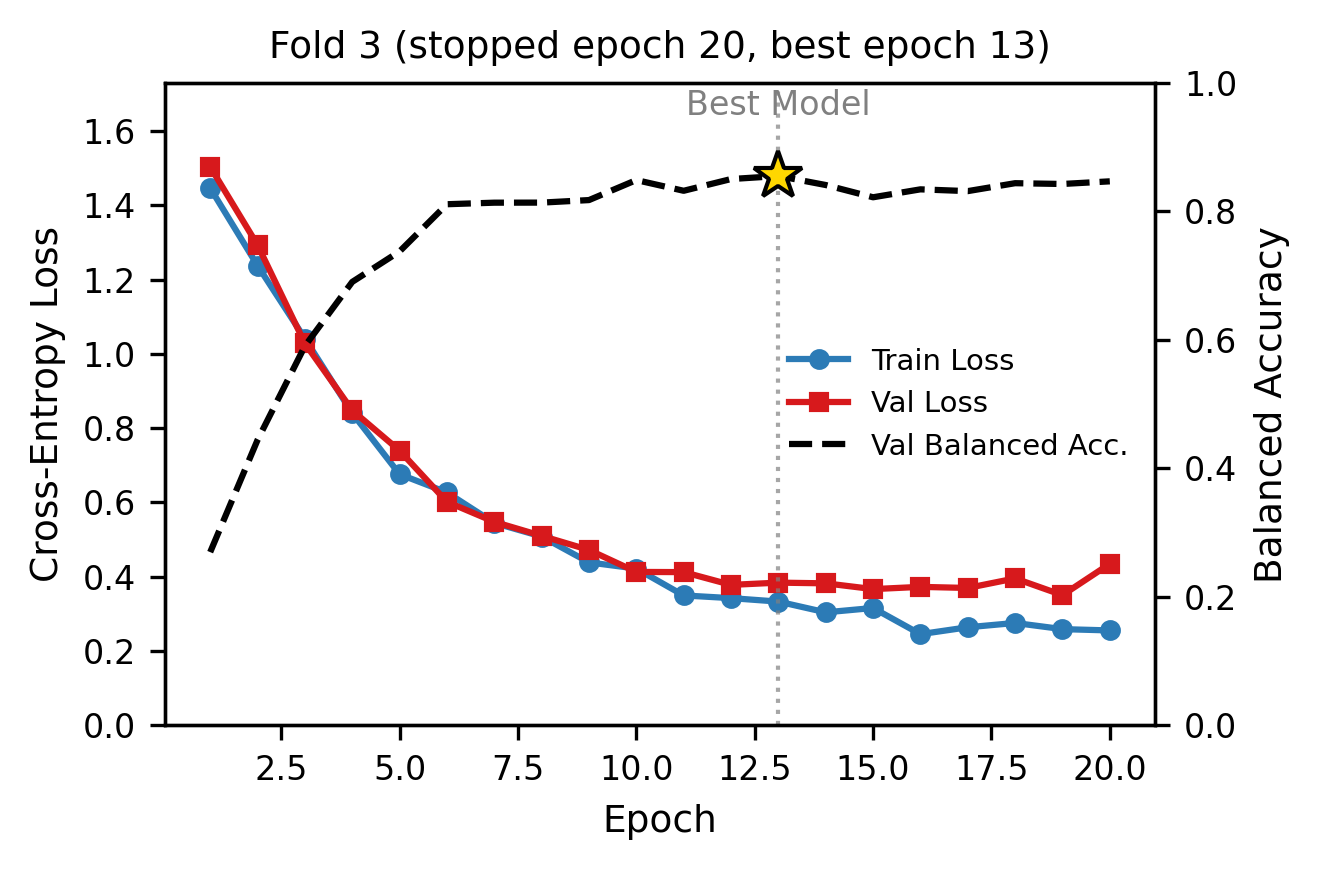

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_fold3_training_curve.png


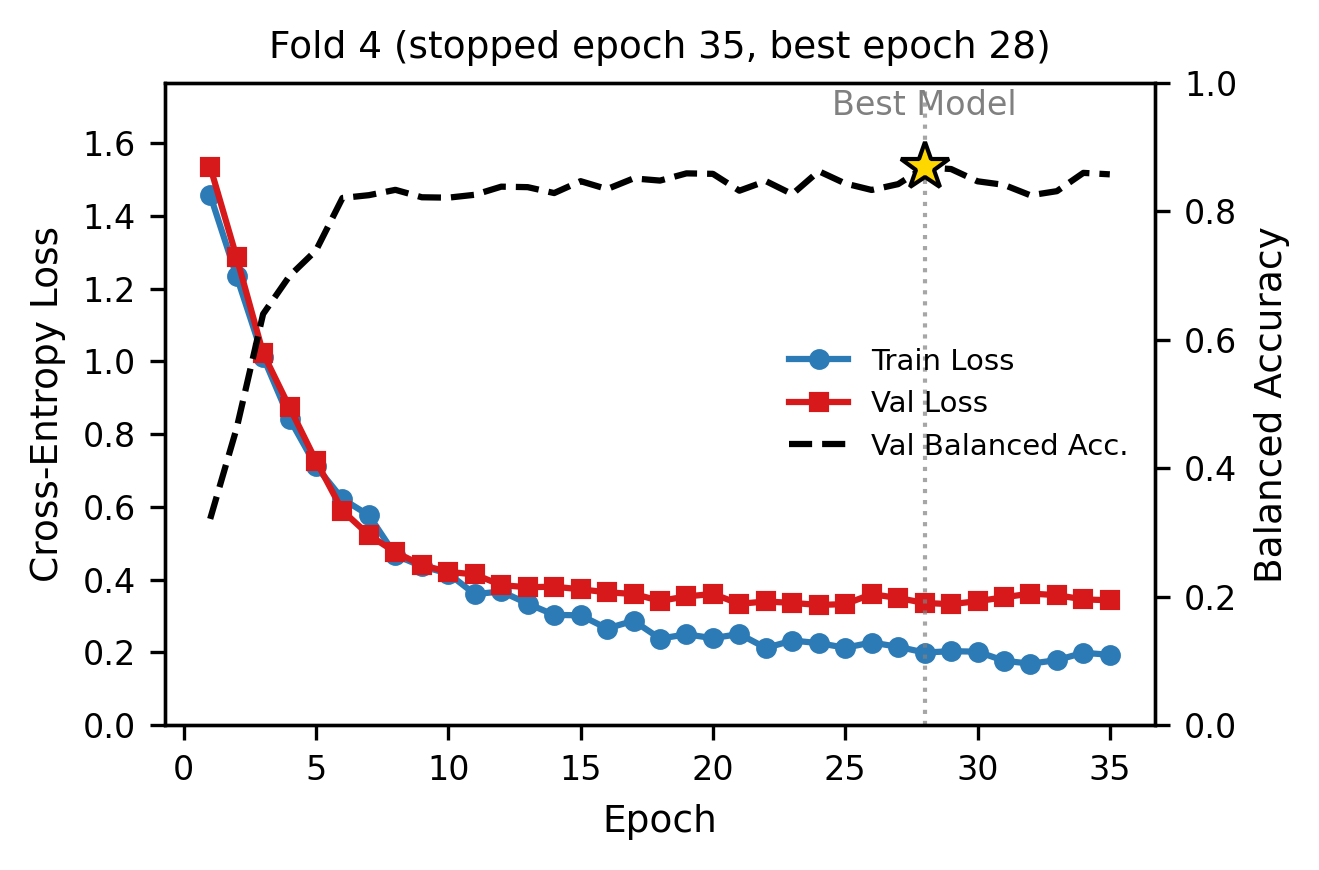

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_fold4_training_curve.png


In [9]:
def plot_fold_training_curve(fold_history, fold_idx, out_path):
    epochs = fold_history["epoch"].values
    train_loss = fold_history["train_loss"].values
    val_loss = fold_history["val_loss"].values
    val_acc = fold_history["val_balanced_accuracy"].values

    best_idx = val_acc.argmax()
    best_epoch = epochs[best_idx]
    best_acc = val_acc[best_idx]

    fig, ax1 = plt.subplots(figsize=(4.5, 3), dpi=300)

    ax1.plot(epochs, train_loss, color="#2c7bb6", linewidth=1.5, label="Train Loss", marker="o", markersize=4)
    ax1.plot(epochs, val_loss, color="#d7191c", linewidth=1.5, label="Val Loss", marker="s", markersize=4)
    ax1.set_xlabel("Epoch", fontsize=9)
    ax1.set_ylabel("Cross-Entropy Loss", fontsize=9)
    ax1.tick_params(axis="both", labelsize=8)
    max_loss = max(train_loss.max(), val_loss.max())
    ax1.set_ylim(0, max_loss * 1.15)

    ax2 = ax1.twinx()
    ax2.plot(epochs, val_acc, color="black", linestyle="--", linewidth=1.5, label="Val Balanced Acc.")
    ax2.set_ylabel("Balanced Accuracy", fontsize=9)
    ax2.set_ylim(0, 1.0)
    ax2.tick_params(axis="y", labelsize=8)

    ax1.axvline(x=best_epoch, color="gray", linestyle=":", linewidth=1, alpha=0.7)
    ax2.plot(best_epoch, best_acc, marker="*", color="gold", markersize=12,
              markeredgecolor="black", zorder=5)
    ax1.text(best_epoch, ax1.get_ylim()[1] * 0.95, "Best Model", fontsize=8, color="gray",
              ha="center" if best_epoch > epochs.max() * 0.2 else "left")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=7, frameon=False, loc="center right")

    ax1.set_title(f"Fold {fold_idx} (stopped epoch {epochs.max()}, best epoch {best_epoch})", fontsize=9)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()


for fold_idx in sorted(history_df["fold"].unique()):
    fold_history = history_df[history_df["fold"] == fold_idx]
    training_curve_fig = checkpoint_dir / f"resnet18_fold{fold_idx}_training_curve.png"
    plot_fold_training_curve(fold_history, fold_idx, training_curve_fig)
    print(f"Saved {training_curve_fig}")